# Hotel-Price-Prediction

In [10]:
# Importing the Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [12]:
# Reading the dataset
df = pd.read_csv('Final_Listings.csv')
df.head()

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,Rental unit in Brooklyn,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55,30,3,20/12/15,0.03,1,0,0,0,5.00,1,1,0
1,Rental unit in New York,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144,30,9,05/01/23,0.24,139,364,2,0,4.67,2,1,1
2,Rental unit in New York,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187,2,6,18/12/23,1.67,1,343,6,1,4.17,1,2,1
3,Rental unit in New York,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120,30,156,17/09/23,1.38,2,363,12,0,4.64,1,1,1
4,Condo in New York,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85,30,11,12/03/23,0.24,133,335,3,0,4.91,0,1,1


In [14]:
# Shape of the datset
print("Shape of the dataset: ", df.shape)

Shape of the dataset:  (20758, 20)


In [16]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            20758 non-null  object 
 1   host_name                       20758 non-null  object 
 2   neighbourhood_group             20758 non-null  object 
 3   neighbourhood                   20758 non-null  object 
 4   latitude                        20758 non-null  float64
 5   longitude                       20758 non-null  float64
 6   room_type                       20758 non-null  object 
 7   price                           20758 non-null  int64  
 8   minimum_nights                  20758 non-null  int64  
 9   number_of_reviews               20758 non-null  int64  
 10  last_review                     20758 non-null  object 
 11  reviews_per_month               20758 non-null  float64
 12  calculated_host_listings_count  

In [18]:
# Describing the numerical columns
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
count,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,40.726798,-73.939161,187.776616,28.558435,42.642596,1.257910,18.844108,205.990317,10.852105,0.153628,3.878539,1.306725,1.723721,1.145582
std,0.060294,0.061403,1022.797208,33.536518,73.561654,1.904661,70.910834,135.087768,21.357071,0.360600,1.841217,0.877419,1.212272,0.452709
min,40.500314,-74.249840,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,40.684150,-73.980710,80.000000,30.000000,4.000000,0.210000,1.000000,87.000000,1.000000,0.000000,4.330000,1.000000,1.000000,1.000000
50%,40.722820,-73.949587,125.000000,30.000000,14.000000,0.650000,2.000000,215.000000,3.000000,0.000000,4.750000,1.000000,1.000000,1.000000
75%,40.763098,-73.917460,199.000000,30.000000,49.000000,1.800000,5.000000,353.000000,15.000000,0.000000,4.910000,2.000000,2.000000,1.000000
max,40.911147,-73.713650,100000.000000,1250.000000,1865.000000,75.490000,713.000000,365.000000,1075.000000,1.000000,5.000000,15.000000,42.000000,15.000000


In [20]:
# knowing the datatypes of columns
df.dtypes

name                               object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                             int64
rating                            float64
bedrooms                            int64
beds                                int64
baths                               int64
dtype: object

In [22]:
# Finding the null values in each column
df.isnull().sum()

name                              0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

In [24]:
# Price above 10000 dollars
df.loc[df['price']>10000]

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
3990,Rental unit in Brooklyn,Bobbi,Brooklyn,Bedford-Stuyvesant,40.69085,-73.93806,Private room,100000,30,29,20/10/23,0.96,2,346,10,0,4.48,1,1,1
5492,Rental unit in Brooklyn,Bobbi,Brooklyn,Bedford-Stuyvesant,40.69254,-73.93636,Private room,100000,30,9,31/10/23,0.45,2,365,5,0,4.33,1,1,1


In [26]:
# Removing the rows with prices above 10000 dollars, these will effect the model accuracy
df = df.loc[df['price']<=10000]

In [28]:
# After removing the rows from the dataset
df.shape

(20756, 20)

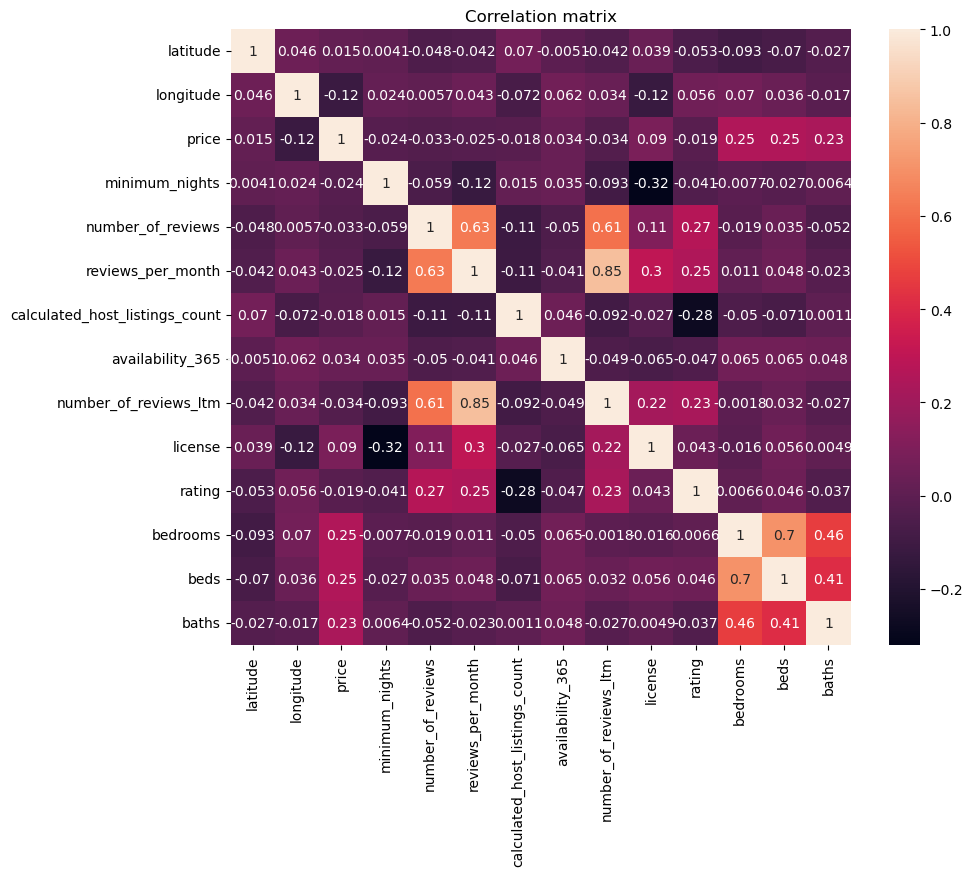

In [30]:
# Correlation Matrix to know relation between the columns 
num_cols = df.select_dtypes(include = ['int64', 'float64']) 

plt.figure(figsize = (10, 8))
sns.heatmap(num_cols.corr(), annot = True)
plt.title("Correlation matrix")
plt.show()

In [31]:
# Categorical columns unique values 
cat_cols = df.select_dtypes(include='object').columns.to_list() 
cat_cols.remove('name') 
cat_cols.remove('host_name') 

for i in cat_cols:
    print(f"For column: {i}")
    print(f"No of unique values: {df[i].nunique()}")
    print(f"Unique values: {df[i].unique()}")
    print("___________________________________")


For column: neighbourhood_group
No of unique values: 5
Unique values: ['Brooklyn' 'Manhattan' 'Queens' 'Bronx' 'Staten Island']
___________________________________
For column: neighbourhood
No of unique values: 221
Unique values: ['Clinton Hill' "Hell's Kitchen" 'Chelsea' 'Washington Heights'
 'Murray Hill' 'Williamsburg' 'Sunset Park' 'Astoria' 'Financial District'
 'Sunnyside' 'Midtown' 'East Elmhurst' 'Upper West Side' 'West Village'
 'Kensington' 'Bushwick' 'Red Hook' 'Tribeca' 'Woodside'
 'Roosevelt Island' 'Concourse Village' 'Harlem' 'Flatbush'
 'University Heights' 'Flushing' 'Greenpoint' 'Ridgewood' 'Cypress Hills'
 "Prince's Bay" 'Port Richmond' 'East Village' 'Clason Point'
 'Bedford-Stuyvesant' 'Gravesend' 'Long Island City' 'Gramercy'
 'East Flatbush' 'East Harlem' 'St. George' 'Boerum Hill'
 'South Ozone Park' 'Park Slope' 'Crown Heights' 'Wakefield'
 'Forest Hills' 'Springfield Gardens' 'North Riverdale' 'Belmont' 'Corona'
 'Tremont' 'Elmhurst' 'Queens Village' 'Prospect

# RandomForestRegressor

In [35]:
# Setting the input(X) and output(y) columns 
X = df.drop('price', axis=1)
y = df['price']

# Getting the dummies for input features 
X = pd.get_dummies(X, drop_first = True)

In [36]:
# Assigning the training and testing data 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [39]:
X_train

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,...,last_review_31/10/22,last_review_31/10/23,last_review_31/12/16,last_review_31/12/17,last_review_31/12/18,last_review_31/12/19,last_review_31/12/20,last_review_31/12/21,last_review_31/12/22,last_review_31/12/23
16965,40.68000,-73.999756,30,125,1.43,2,269,11,0,4.74,...,False,True,False,False,False,False,False,False,False,False
1846,40.74936,-73.971960,30,3,0.02,2,87,0,0,4.67,...,False,False,False,False,False,False,False,False,False,False
14227,40.66988,-73.983460,180,174,1.91,1,149,37,0,4.99,...,False,False,False,False,False,False,False,False,False,False
9440,40.67599,-73.941970,30,50,2.98,15,365,30,0,4.74,...,False,False,False,False,False,False,False,False,False,False
12461,40.67300,-73.987570,30,3,0.13,32,364,0,0,4.33,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11286,40.65819,-73.769690,30,43,0.74,5,0,1,0,4.58,...,False,False,False,False,False,False,False,False,False,False
11966,40.72880,-73.724430,30,18,0.81,1,178,9,0,4.78,...,False,False,False,False,False,False,False,False,False,False
5391,40.68593,-73.958140,35,41,3.03,1,180,38,0,4.66,...,False,False,False,False,False,False,False,False,False,False
860,40.77692,-73.980420,30,10,0.19,1,0,0,0,4.40,...,False,False,False,False,False,False,False,False,False,False


In [40]:
y_train

16965     150
1846     1364
14227     200
9440       70
12461      53
         ... 
11286      30
11966      50
5391      104
860       315
15797     250
Name: price, Length: 14529, dtype: int64

In [41]:
print("Shape of X_test data", X_test.shape)
print("Shape of the y_test data", y_test.shape)

Shape of X_test data (6227, 8292)
Shape of the y_test data (6227,)


In [45]:
# Creating and fitting model for our training data 
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf.score(X_train, y_train) # getting the performance score of the model 

0.8983909225829556

In [46]:
# Fitting the model for test data
rf.fit(X_test, y_test)
rf.score(X_test, y_test)

0.8714837375913548

In [47]:
# y_pred 
y_pred = rf.predict(X_test)

In [48]:
# Finding the evaluation metrics for the model to know the model behaviour
mse_rf = mean_squared_error(y_test, y_pred)
mae_rf = mean_absolute_error(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred)

print(f"MSE: {mse_rf}")
print(f"MAE: {mae_rf}")
print(f"R²: {r2_rf}")

MSE: 10687.83233984262
MAE: 24.390412718805198
R²: 0.8714837375913548


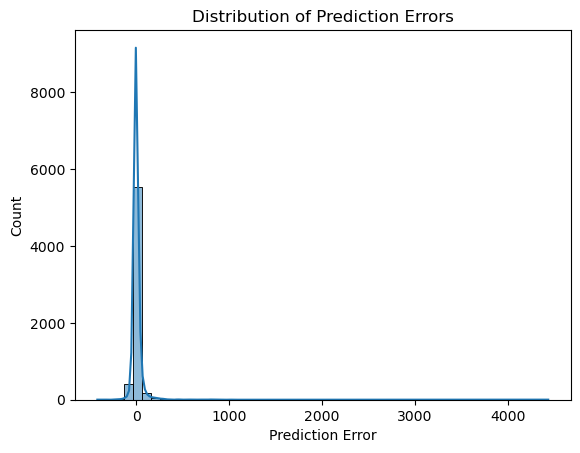

In [49]:
# Plotting the distribution for prediction errors 
errors = y_test - y_pred
sns.histplot(errors, bins = 50, kde = True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.show()

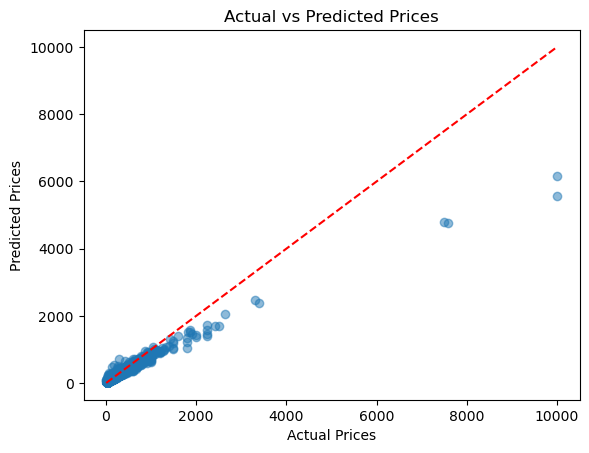

In [50]:
# Plotting the scatter plot with a regression line for knowing the model performance 
plt.scatter(y_test, y_pred, alpha = 0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect line
plt.show()